# Configurações, Caminhos e Importações

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import glob
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from sklearn.model_selection import train_test_split
from google.colab import drive

# Seeds para reprodutibilidade
RANDOM_SEED = 42
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

drive.mount('/content/drive')

# --- CONFIGURAÇÃO DE CAMINHOS ---
dataset_path = '/content/drive/MyDrive/TCC/PKG - Osteosarcoma Tumor Assessment'
csv_path = '/content/drive/MyDrive/TCC/ML_Features_1144.csv'
save_model_path = '/content/drive/MyDrive/TCC/Modelos_Osteosarcoma'

os.makedirs(save_model_path, exist_ok=True)

# NOMES PARA A MOBILENET V2
checkpoint_path = os.path.join(save_model_path, 'melhor_modelo_MobileNetV2_3classes_CLAHE_temp.keras')
final_model_name = os.path.join(save_model_path, 'MobileNetV2_Osteosarcoma_3classes_CLAHE_Final.keras')

IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 100

Mounted at /content/drive


# Função CLAHE (YUV) + Pré-processamento MobileNetV2

In [ ]:
def apply_clahe_mobilenet(image):
    """
    Converte RGB -> YUV, aplica CLAHE no canal Y, retorna para RGB e
    aplica o preprocess_input específico da MobileNetV2.
    """
    img_uint8 = image.astype('uint8')

    # 1. Converter de RGB para YUV
    yuv = cv2.cvtColor(img_uint8, cv2.COLOR_RGB2YUV)

    # 2. Aplicar CLAHE no canal de Luminância (Y)
    clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
    yuv[:,:,0] = clahe.apply(yuv[:,:,0])

    # 3. Converter de volta para RGB
    img_final = cv2.cvtColor(yuv, cv2.COLOR_YUV2RGB)

    # 4. Aplicar o preprocessamento da ImageNet específico para a MobileNetV2
    img_preprocessed = preprocess_input(img_final.astype('float32'))

    return img_preprocessed

# Mapeamento e Agrupamento das 3 Classes

In [ ]:
print("Iniciando carregamento e agrupamento (3 Classes)...")
df_original = pd.read_csv(csv_path)

# Criando uma cópia
df_copia = df_original.copy()

# ==============================================================================
# ALTERAÇÃO DO DATASET: Mesclando 'viable: non-viable' em 'Viable'
# ==============================================================================
df_copia['classification'] = df_copia['classification'].replace('viable: non-viable', 'Viable')

print("\nDistribuição de Classes para a MobileNetV2:")
print(df_copia['classification'].value_counts())

all_image_paths = glob.glob(os.path.join(dataset_path, '**', '*.jpg'), recursive=True)
all_image_paths += glob.glob(os.path.join(dataset_path, '**', '*.JPG'), recursive=True)

normalized_path_lookup = {}
for p in all_image_paths:
    base = os.path.basename(p)
    name_no_ext = os.path.splitext(base)[0]
    norm_name = name_no_ext.lower().replace(" ", "").replace("-", "").replace("_", "")
    normalized_path_lookup[norm_name] = p

def get_full_path_robust(image_name):
    if pd.isna(image_name): return None
    norm_csv_name = str(image_name).lower().replace(" ", "").replace("-", "").replace("_", "")
    return normalized_path_lookup.get(norm_csv_name)

df_copia['full_path'] = df_copia['image.name'].apply(get_full_path_robust)
df_final = df_copia.dropna(subset=['full_path']).copy()

print(f"\nTotal de imagens mapeadas: {len(df_final)} / 1144")

Iniciando carregamento e agrupamento (3 Classes)...

Distribuição de Classes para a MobileNetV2:
classification
Non-Tumor           536
Viable              345
Non-Viable-Tumor    263
Name: count, dtype: int64

Total de imagens mapeadas: 1144 / 1144


# Divisão e Geradores

In [ ]:
train_df, temp_df = train_test_split(
    df_final, train_size=0.7, stratify=df_final['classification'], random_state=RANDOM_SEED
)
val_df, test_df = train_test_split(
    temp_df, train_size=0.5, stratify=temp_df['classification'], random_state=RANDOM_SEED
)

# Gerador com CLAHE e Pré-processamento acoplado
datagen = ImageDataGenerator(preprocessing_function=apply_clahe_mobilenet)

train_gen = datagen.flow_from_dataframe(
    train_df, x_col='full_path', y_col='classification',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=True
)

val_gen = datagen.flow_from_dataframe(
    val_df, x_col='full_path', y_col='classification',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

test_gen = datagen.flow_from_dataframe(
    test_df, x_col='full_path', y_col='classification',
    target_size=IMG_SIZE, batch_size=BATCH_SIZE, class_mode='categorical', shuffle=False
)

Found 800 validated image filenames belonging to 3 classes.
Found 172 validated image filenames belonging to 3 classes.
Found 172 validated image filenames belonging to 3 classes.


# Arquitetura MobileNetV2 e Treinamento

In [ ]:
def build_model_osteo_mobilenet(num_classes=3):
    base_model = MobileNetV2(weights='imagenet', include_top=False, input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3))
    base_model.trainable = False

    x = base_model.output
    x = GlobalAveragePooling2D()(x)
    x = Dropout(0.3)(x)
    predictions = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=predictions)
    model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])
    return model

model = build_model_osteo_mobilenet(num_classes=3)

callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ModelCheckpoint(checkpoint_path, monitor='val_loss', save_best_only=True, verbose=1)
]

print("Iniciando Treinamento (MobileNetV2 | 3 Classes | CLAHE YUV)...")
history = model.fit(
    train_gen, validation_data=val_gen,
    epochs=EPOCHS, callbacks=callbacks, verbose=1
)

model.save(final_model_name)
print(f"Treinamento concluído! Modelo salvo em: {final_model_name}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Iniciando Treinamento (MobileNetV2 | 3 Classes | CLAHE YUV)...
Epoch 1/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 10s/step - accuracy: 0.4596 - loss: 1.1685
Epoch 1: val_loss improved from None to 0.46033, saving model to /content/drive/MyDrive/TCC/Modelos_Osteosarcoma/melhor_modelo_MobileNetV2_3classes_CLAHE_temp.keras

Epoch 1: finished saving model to /content/drive/MyDrive/TCC/Modelos_Osteosarcoma/melhor_modelo_MobileNetV2_3classes_CLAHE_temp.keras
25/25 ━━━━━━━━━━━━━━━━━━━━ 346s 13s/step - accuracy: 0.5838 - loss: 0.9195 - val_accuracy: 0.7965 - val_loss: 0.4603
Epoch 2/100
25/25 ━━━━━━━━━━━━━━━━━━━━ 0s 359ms/step - accuracy: 0.7826 - loss: 0.4960
Epoch 2: val_loss improved from 0.46033 to 0.35574, saving model to /content/drive/MyDrive/TCC/Modelos_Osteosarcoma/melhor_modelo_MobileNetV2_3classes_CLAHE_temp.keras

Epoch 2: finished saving model to /content/drive/MyDrive/TCC/Modelos_Osteosarcoma/melhor_modelo_MobileNetV2_3classes_CLAHE_temp.ke

# Avaliação Final

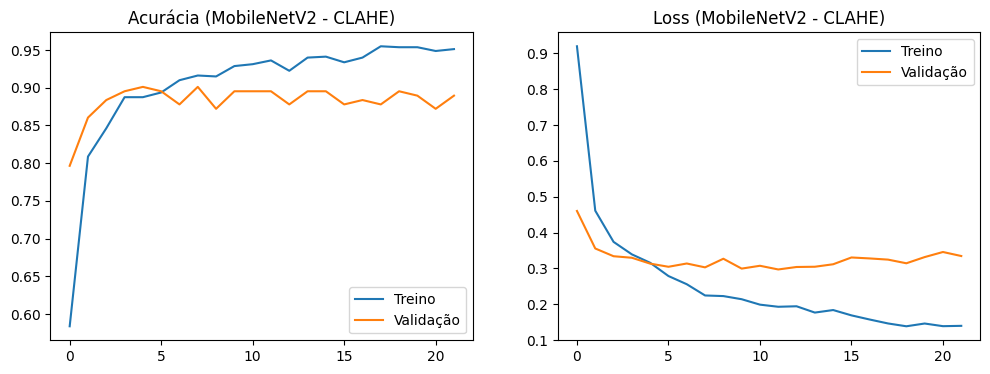

6/6 ━━━━━━━━━━━━━━━━━━━━ 48s 8s/step

--- RELATÓRIO DE CLASSIFICAÇÃO (MobileNetV2) ---
                  precision    recall  f1-score   support

       Non-Tumor     0.9268    0.9383    0.9325        81
Non-Viable-Tumor     0.8780    0.9231    0.9000        39
          Viable     0.9184    0.8654    0.8911        52

        accuracy                         0.9128       172
       macro avg     0.9077    0.9089    0.9079       172
    weighted avg     0.9132    0.9128    0.9126       172



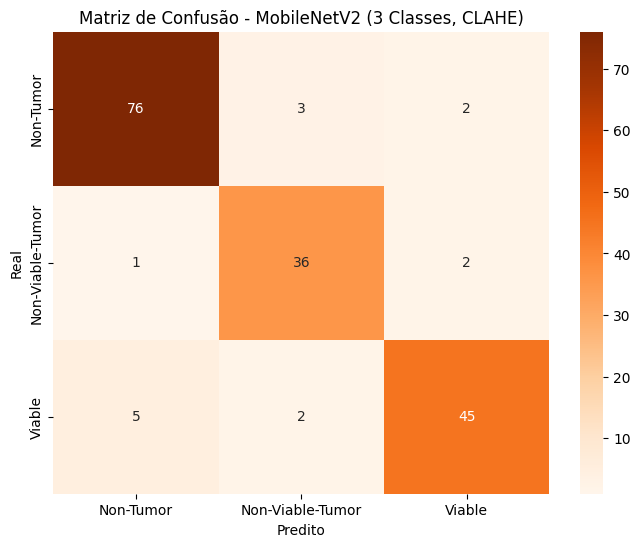

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# 1. Gráficos de Evolução do Treino
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Treino')
plt.plot(history.history['val_accuracy'], label='Validação')
plt.title('Acurácia (MobileNetV2 - CLAHE)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Treino')
plt.plot(history.history['val_loss'], label='Validação')
plt.title('Loss (MobileNetV2 - CLAHE)')
plt.legend()
plt.show()

# 2. Predição no conjunto de Teste
test_gen.reset()
Y_pred = model.predict(test_gen)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_gen.classes
class_labels = list(test_gen.class_indices.keys())

# 3. Relatório de Classificação Detalhado
print("\n--- RELATÓRIO DE CLASSIFICAÇÃO (MobileNetV2) ---")
print(classification_report(y_true, y_pred, target_names=class_labels, digits=4))

# 4. Matriz de Confusão
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', xticklabels=class_labels, yticklabels=class_labels)
plt.xlabel('Predito')
plt.ylabel('Real')
plt.title('Matriz de Confusão - MobileNetV2 (3 Classes, CLAHE)')
plt.show()